# EDA - Population mixte

## Importation des données / librairies

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import entropy
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import matplotlib.cm as cm

In [2]:
name_of_file_in_bucket = "aou_admixture_estimates_rye_v8.Q"

########################################################################
##
################# DON'T CHANGE FROM HERE ###############################
##
########################################################################

# get the bucket name
my_bucket = os.getenv('WORKSPACE_BUCKET')

# copy csv file from the bucket to the current working space
os.system(f"gsutil cp '{my_bucket}/Data/{name_of_file_in_bucket}' .")

print(f'[INFO] {name_of_file_in_bucket} is successfully downloaded into your working space')
# save dataframe in a csv file in the same workspace as the notebook
df_rye = pd.read_csv(name_of_file_in_bucket, sep='\t')
df_rye.head()

Copying gs://fc-secure-4f907dc3-1aa1-4aaa-8566-86d601589221/Data/aou_admixture_estimates_rye_v8.Q...
/ [1 files][ 32.4 MiB/ 32.4 MiB]                                                
Operation completed over 1 objects/32.4 MiB.                                     


[INFO] aou_admixture_estimates_rye_v8.Q is successfully downloaded into your working space


,eur,eas,amr,afr,sas,mid,research_id
0,0.000000,0.002611,0.000000,0.940905,0.000000,0.056484,1000000
1,0.892052,0.000000,0.063450,0.000000,0.000000,0.044498,1000004
2,0.886335,0.000000,0.039803,0.000000,0.073862,0.000000,1000033
3,0.045004,0.003594,0.000000,0.874350,0.003528,0.073524,1000039
4,0.115799,0.014158,0.000000,0.853614,0.000000,0.016430,1000042


## Description des données

In [3]:
df_rye.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414830 entries, 0 to 414829
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   eur          414830 non-null  float64
 1   eas          414830 non-null  float64
 2   amr          414830 non-null  float64
 3   afr          414830 non-null  float64
 4   sas          414830 non-null  float64
 5   mid          414830 non-null  float64
 6   research_id  414830 non-null  int64  
dtypes: float64(6), int64(1)
memory usage: 22.2 MB


In [4]:
df_rye.describe()

,eur,eas,amr,afr,sas,mid,research_id
count,414830.000000,414830.000000,414830.000000,414830.000000,414830.000000,414830.000000,4.148300e+05
mean,0.532830,0.027264,0.156998,0.176055,0.033638,0.073215,3.471125e+06
std,0.384990,0.147788,0.307381,0.328919,0.095619,0.120482,2.452574e+06
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+06
25%,0.101485,0.000000,0.000000,0.000000,0.000000,0.000000,1.664706e+06
50%,0.659953,0.000000,0.030852,0.000000,0.016030,0.034390,2.537397e+06
75%,0.905919,0.000000,0.063851,0.066691,0.042200,0.075637,4.569300e+06
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,9.999860e+06


## Analyse univariée

/tmp/ipykernel_893/2998098789.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  blues_cmap = cm.get_cmap('Blues', len(pop_cols))  # discretise la colormap


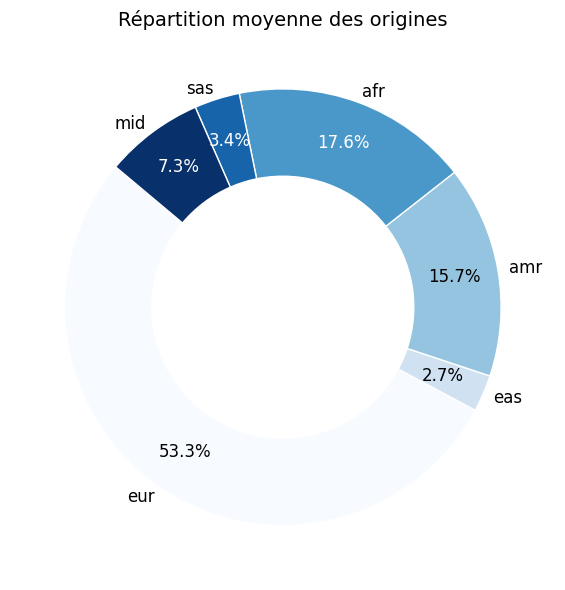

In [5]:
# Définir les colonnes de populations
pop_cols = ['eur', 'eas', 'amr', 'afr', 'sas', 'mid']

df_mean = df_rye[pop_cols].mean()

# Génération de n couleurs issues de la colormap 'Blues'
blues_cmap = cm.get_cmap('Blues', len(pop_cols))  # discretise la colormap
colors = [blues_cmap(i) for i in range(len(pop_cols))]  # récupère une couleur pour chaque segment

# Fonction pour déterminer couleur du texte (noir ou blanc) selon la luminosité
def get_text_color(rgb):
    r, g, b = rgb[:3]
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return 'black' if luminance > 0.6 else 'white'

# Création du pie chart
plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(
    df_mean,
    labels=pop_cols,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    labeldistance=1.05,
    pctdistance=0.8,
    wedgeprops=dict(width=0.4, edgecolor='white'),
    textprops=dict(fontsize=12)
)

# Adapter dynamiquement la couleur du texte en % selon le fond
for autotext, color in zip(autotexts, colors):
    autotext.set_color(get_text_color(color))
    autotext.set_fontsize(12)

plt.title("Répartition moyenne des origines", fontsize=14)
plt.tight_layout()
# Sauvegarde avant affichage
plt.savefig("figs/all_average_distribution_of_organs.png", dpi=300, bbox_inches='tight')
plt.show()

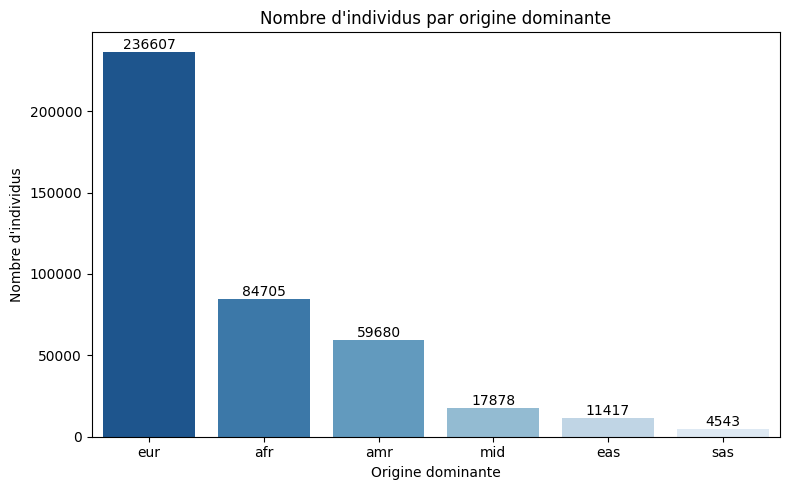

In [6]:
# Identifier l'origine dominante
df_rye['dominant_origin'] = df_rye[pop_cols].idxmax(axis=1)

# Comptage du nombre d'individus par origine dominante
origin_counts = df_rye['dominant_origin'].value_counts().sort_values(ascending=False)

# Création du graphique
plt.figure(figsize=(8, 5))
bars = sns.barplot(
    x=origin_counts.index,
    y=origin_counts.values,
    palette=reversed(sns.color_palette("Blues", n_colors=len(origin_counts)))
)

# Ajouter les annotations
for i, count in enumerate(origin_counts.values):
    plt.text(i, count + 0.1, str(count), ha='center', va='bottom', fontsize=10)

# Personnalisation
plt.xlabel("Origine dominante")
plt.ylabel("Nombre d'individus")
plt.title("Nombre d'individus par origine dominante")

plt.tight_layout()
# Sauvegarde avant affichage
plt.savefig("figs/all_number_of_individuals_by_dominant_origin.png", dpi=300, bbox_inches='tight')
plt.show()

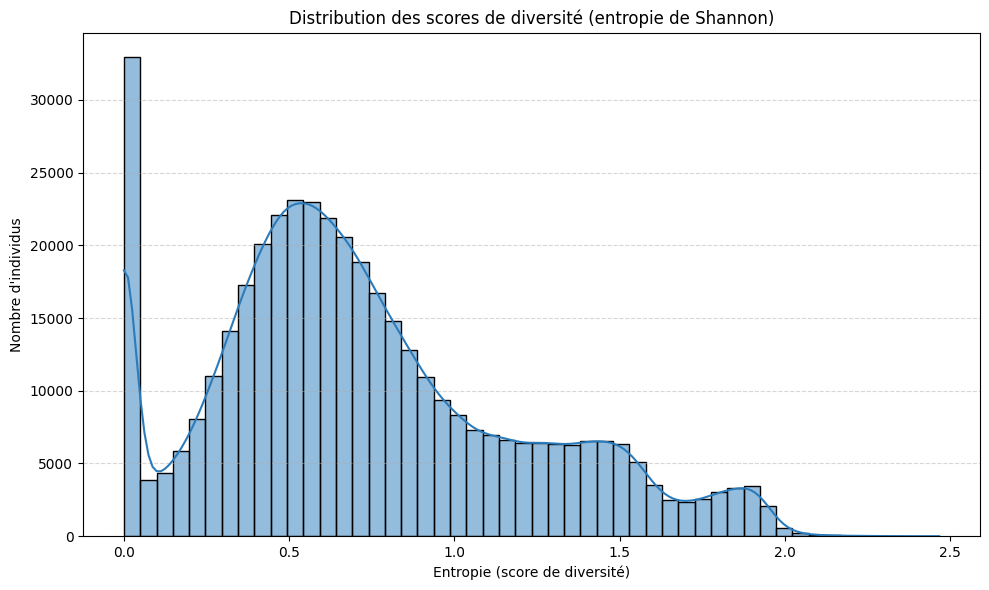

In [7]:
# Calcul de l'entropie (score de diversité) pour chaque individu
df_rye['diversity_entropy'] = df_rye[pop_cols].apply(lambda x: entropy(x + 1e-10, base=2), axis=1)

# Visualisation sous forme d'histogramme
plt.figure(figsize=(10, 6))
sns.histplot(
    df_rye['diversity_entropy'],
    bins=50,
    kde=True,
    color=sns.color_palette("Blues", n_colors=6)[-2]
)

# Personnalisation
plt.xlabel("Entropie (score de diversité)")
plt.ylabel("Nombre d'individus")
plt.title("Distribution des scores de diversité (entropie de Shannon)")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
# Sauvegarde avant affichage
plt.savefig("figs/all_distribution_of_diversity_scores_(Shannon_entropy).png", dpi=300, bbox_inches='tight')
plt.show()

Le +1e-10 évite les log(0) dans l'entropie.

Tu peux combiner les deux graphes côte à côte avec plt.subplot si tu veux.

Le score d'entropie varie entre 0 (profil 100% homogène) et ~2.58 (profil totalement équilibré entre 6 origines).

Tu peux identifier visuellement :

les individus à forte diversité génétique (entropie élevée),

ceux à origine unique dominante (entropie proche de 0).

# Au moins 0.8 dans une categorie

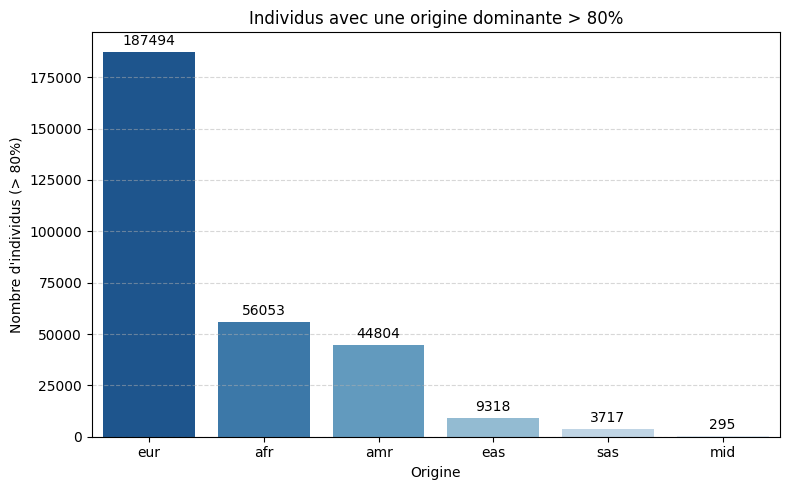

In [8]:
# Seuil de dominance
threshold = 0.8

# Comptage du nombre d'individus avec une proportion > seuil pour chaque origine
count_per_category = (df_rye[pop_cols] > threshold).sum().sort_values(ascending=False)

# Graphique
plt.figure(figsize=(8, 5))
sns.barplot(
    x=count_per_category.index,
    y=count_per_category.values,
    palette=reversed(sns.color_palette("Blues", n_colors=len(count_per_category)))
)

# Annotations
for i, count in enumerate(count_per_category.values):
    plt.text(i, count + max(count_per_category.values)*0.01, str(count), ha='center', va='bottom', fontsize=10)

# Personnalisation
plt.xlabel("Origine")
plt.ylabel(f"Nombre d'individus (> {threshold*100:.0f}%)")
plt.title(f"Individus avec une origine dominante > {threshold*100:.0f}%")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
# Sauvegarde avant affichage
plt.savefig("figs/all_individuals_with_a_dominant_origin_(0,8).png", dpi=300, bbox_inches='tight')
plt.show()

# 0.8 Au total de 2 categories mais < 0.8 dans chaque

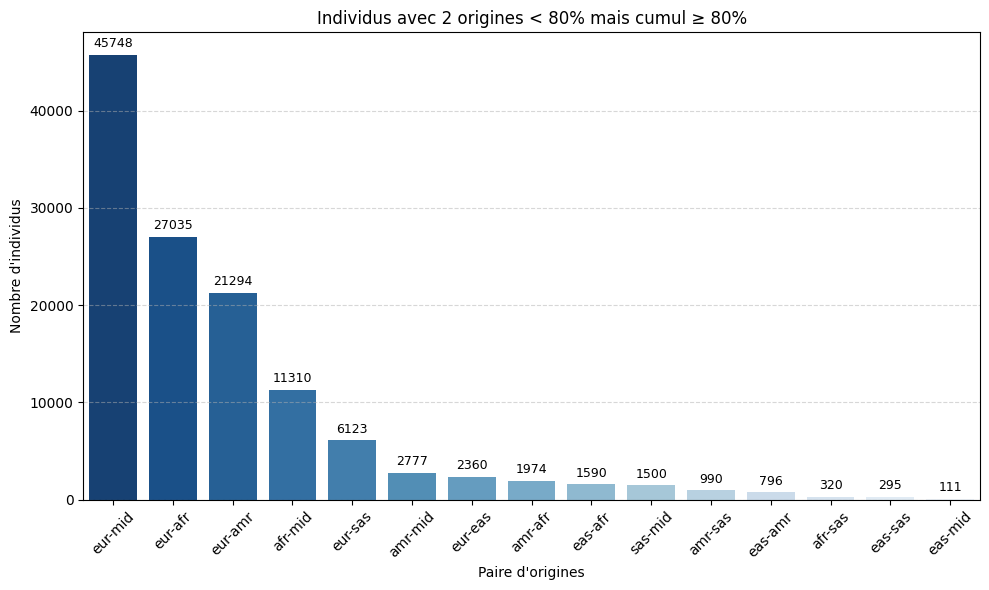

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# Seuil
threshold = 0.8
category_cols = ['eur', 'eas', 'amr', 'afr', 'sas', 'mid']

# Calcul du nombre d'individus pour chaque paire d'origines
corrected_pairwise_results = []

for cat1, cat2 in combinations(category_cols, 2):
    sum_pair = df_rye[cat1] + df_rye[cat2]
    both_below_threshold = (df_rye[cat1] < threshold) & (df_rye[cat2] < threshold)
    condition = (sum_pair >= threshold) & both_below_threshold
    count = condition.sum()
    corrected_pairwise_results.append({'pair': f'{cat1}-{cat2}', 'count': count})

# Création DataFrame pour visualisation
corrected_pairwise_df = pd.DataFrame(corrected_pairwise_results).sort_values(by='count', ascending=False)

# Graphique
plt.figure(figsize=(10, 6))
bars = sns.barplot(
    x='pair',
    y='count',
    data=corrected_pairwise_df,
    palette=reversed(sns.color_palette("Blues", n_colors=len(corrected_pairwise_df)))
)

# Annotations
for i, count in enumerate(corrected_pairwise_df['count']):
    plt.text(i, count + max(corrected_pairwise_df['count']) * 0.01, str(count), ha='center', va='bottom', fontsize=9)

# Personnalisation
plt.xlabel("Paire d'origines")
plt.ylabel("Nombre d'individus")
plt.title(f"Individus avec 2 origines < {threshold*100:.0f}% mais cumul ≥ {threshold*100:.0f}%")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)

plt.tight_layout()
# Sauvegarde avant affichage
plt.savefig("figs/all_individuals_with_2_origins_<_0,8_but_cumulative_>_0,8.png", dpi=300, bbox_inches='tight')
plt.show()